# Stage 1 + 2 — Coulomb-Counting Baseline & UKF SOC Estimator

This notebook is the working core of the project. We do two things:

1. **Establish the Coulomb-counting (CC) baseline** that any "smarter" estimator has to beat. CC is the same math as Stage 0's ground truth, but treated as a *causal* estimator subject to realistic problems: unknown initial SOC and current-sensor DC bias.
2. **Build a UKF SOC estimator** on a 1RC equivalent-circuit model with **fixed** parameters chosen from the data, and compare it head-to-head with CC across four scenarios.

The whole point of fixing parameters here is to set up Stage 3, which will replace them with values predicted by an LSTM. So the comparison is the contract:

> *Stage 2's UKF must clearly beat CC on initial-state and bias errors; its remaining gap (especially on aged cells) is what Stage 3 attacks.*

Battery: **B0005** throughout — fresh through 168 discharge cycles, room-temperature, 30 % fade EOL.


## 1. Setup

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from utils import (
    Q_NOMINAL_AH,
    load_metadata, load_discharge_ground_truth, discharge_metadata,
    coulomb_count, BatteryUKF,
    rmse, mae, max_abs_err,
)

BATTERY = 'B0005'
plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['axes.grid'] = True

gt   = load_discharge_ground_truth(BATTERY)
disc = discharge_metadata(BATTERY)
meta = load_metadata(BATTERY)

def get_cycle(cycle_num):
    c = gt[gt['cycle_num'] == cycle_num].reset_index(drop=True)
    return (c['time_s'].to_numpy(), c['current'].to_numpy(),
            c['voltage'].to_numpy(), c['soc_nominal'].to_numpy())

CYCLE_FRESH, CYCLE_AGED = 1, 100
t1, i1, v1, soc1_truth     = get_cycle(CYCLE_FRESH)
t100, i100, v100, soc100_t = get_cycle(CYCLE_AGED)

print(f'Cycle {CYCLE_FRESH:3d}: SOH={disc.iloc[CYCLE_FRESH-1].SOH:.3f}, {len(t1)} samples')
print(f'Cycle {CYCLE_AGED:3d}: SOH={disc.iloc[CYCLE_AGED-1].SOH:.3f}, {len(t100)} samples')


Cycle   1: SOH=0.928, 197 samples
Cycle 100: SOH=0.743, 322 samples


## 2. Sanity check — measured vs commanded current

Before getting into failure modes, one quick reality check on the **current measurement itself**. NASA's discharge protocol commands a constant -2.0 A. The current sensor reads close to that, but not exactly:

- Measurement noise ($\sigma$ ≈ 1.5 mA on top of the setpoint)
- A small systematic deviation from -2.0 A in the CC phase
- A brief spike at load engagement and a tail at disconnect

If we compare CC running on the **measured** current vs. CC running on a synthetic **commanded** current (= -2.0 A wherever the cell is actively discharging, 0 elsewhere), we isolate the impact of those measurement deviations on the SOC trajectory — *separately* from any sensor bias we add later.


Measured I in CC region: mean = -2.0126 A, std = 0.0015 A
Commanded I              : exactly -2.0000 A
Active-discharge duration: 3311 s

Charge extracted (measured I): 1.8622 Ah
Charge extracted (ideal -2A) : 1.8503 Ah


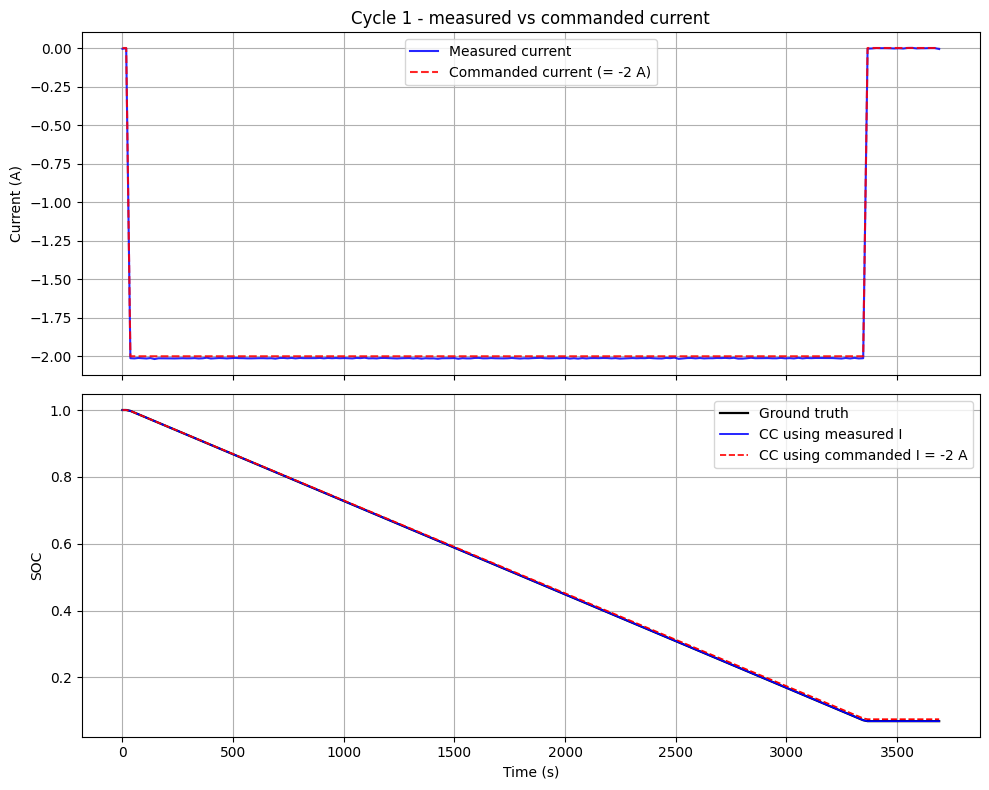

,estimator,RMSE,final SOC,final err
0,CC measured I,0.00000,0.06890,0.00000
1,CC commanded I,0.00363,0.07483,0.00592
2,Ground truth,0.00000,0.06890,0.00000


In [6]:
# Build the 'commanded' current trace: protocol-level -2.0 A during active discharge
mask_active = i1 < -1.0
i_commanded = np.where(mask_active, -2.0, 0.0)

print(f'Measured I in CC region: mean = {i1[mask_active].mean():+.4f} A, std = {i1[mask_active].std():.4f} A')
print(f'Commanded I              : exactly -2.0000 A')
print(f'Active-discharge duration: {t1[mask_active][-1] - t1[mask_active][0]:.0f} s')
print()
print(f'Charge extracted (measured I): {-np.trapezoid(i1, t1) / 3600:.4f} Ah')
print(f'Charge extracted (ideal -2A) : {-np.trapezoid(i_commanded, t1) / 3600:.4f} Ah')

soc_cc_measured  = coulomb_count(t1, i1,          soc_init=1.0, q_ah=Q_NOMINAL_AH)
soc_cc_commanded = coulomb_count(t1, i_commanded, soc_init=1.0, q_ah=Q_NOMINAL_AH)

fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
axes[0].plot(t1, i1,          'b-',  alpha=0.85, label='Measured current')
axes[0].plot(t1, i_commanded, 'r--', alpha=0.85, label='Commanded current (= -2 A)')
axes[0].set_ylabel('Current (A)')
axes[0].set_title('Cycle 1 - measured vs commanded current')
axes[0].legend()

axes[1].plot(t1, soc1_truth,         'k-',  lw=1.6, label='Ground truth')
axes[1].plot(t1, soc_cc_measured,    'b-',  lw=1.2, label='CC using measured I')
axes[1].plot(t1, soc_cc_commanded,   'r--', lw=1.2, label='CC using commanded I = -2 A')
axes[1].set_ylabel('SOC')
axes[1].set_xlabel('Time (s)')
axes[1].legend()
plt.tight_layout(); plt.show()

import pandas as pd
pd.DataFrame([
    {'estimator': 'CC measured I',  'RMSE': rmse(soc1_truth, soc_cc_measured),  'final SOC': soc_cc_measured[-1],  'final err': soc_cc_measured[-1]-soc1_truth[-1]},
    {'estimator': 'CC commanded I', 'RMSE': rmse(soc1_truth, soc_cc_commanded), 'final SOC': soc_cc_commanded[-1], 'final err': soc_cc_commanded[-1]-soc1_truth[-1]},
    {'estimator': 'Ground truth',   'RMSE': 0.0, 'final SOC': soc1_truth[-1], 'final err': 0.0},
]).round(5)


**What this tells us**

- **Measured-I CC matches ground truth exactly** (RMSE = 0). This is by construction — Stage 0's ground truth *is* the integral of the measured current. The two are the same calculation.
- **Commanded-I CC drifts by ~0.4 %** over the cycle (final SOC 0.075 vs truth 0.069). The measured current is on average 13 mA *more negative* than commanded, so assuming an ideal -2 A under-reports the actual charge extracted. After 55 minutes that's a 6-mAh shortfall — small here, larger over a real driving cycle.
- **The disagreement is bounded by the ~13 mA setpoint deviation**, not by integration error. If you knew the *true* commanded current to the milliamp you'd close the gap; if you trusted only the measured sensor, you'd already be at ground truth.

**Implication for the rest of this notebook**: every "perfect CC" baseline below uses the **measured** current, so it overlaps ground truth exactly. The failure modes we add next (wrong SOC₀, sensor bias) sit *on top of* that baseline. The tiny commanded-vs-measured gap is real but dwarfed by the realistic failures we're about to demonstrate.


## 3. Coulomb-counting baseline — the failure modes we have to beat

Pure Coulomb counting is just $\text{SOC}(t) = \text{SOC}(0) + \frac{1}{Q}\int I\,d\tau$. With perfect inputs it reproduces ground truth (machine precision — verified in Stage 0). But it has **two structural failure modes**:

| # | Failure | Why it matters | Signature |
|---|---|---|---|
| 1 | **Unknown SOC(0)** — in deployment we don't know the starting state | Open-loop integrator preserves whatever you start with | Constant-offset error; never self-corrects |
| 2 | **Current-sensor DC bias** — real shunts have offsets of tens of mA | Bias × time = drift in the integral | Error grows linearly with time at slope = bias / Q |

We demonstrate both at once with a single combined-failure scenario and record the numbers we need to beat.


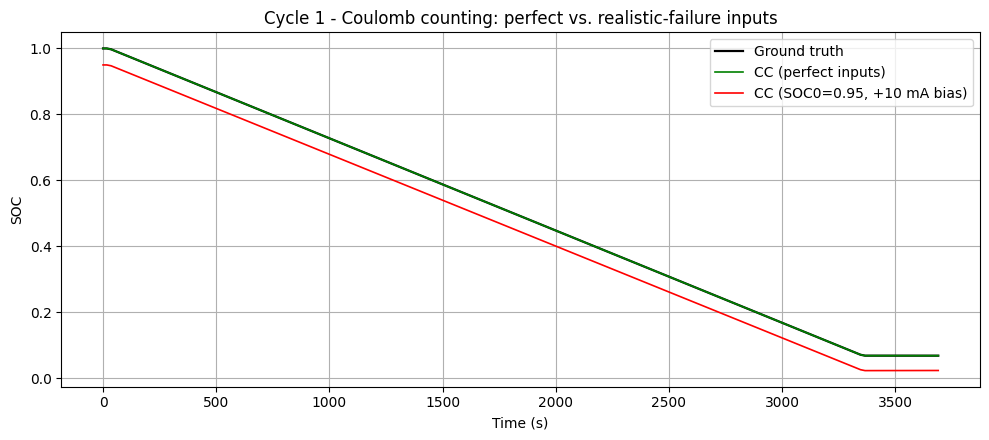

,estimator,RMSE,final err
0,CC perfect,0.00000,0.00000
1,CC SOC0=0.95 + 10 mA bias,0.04751,-0.04487


In [7]:
# Combined-failure CC: 5% wrong SOC0 and +10 mA current bias
soc0_guess = 0.95
bias_a     = 0.010

cc_perfect  = coulomb_count(t1, i1,             soc_init=1.0,        q_ah=Q_NOMINAL_AH)
cc_fail     = coulomb_count(t1, i1 + bias_a,    soc_init=soc0_guess, q_ah=Q_NOMINAL_AH)

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(t1, soc1_truth, 'k-', lw=1.6, label='Ground truth')
ax.plot(t1, cc_perfect, 'g-', lw=1.2, label='CC (perfect inputs)')
ax.plot(t1, cc_fail,    'r-', lw=1.2, label=f'CC (SOC0={soc0_guess}, +{int(bias_a*1000)} mA bias)')
ax.set_xlabel('Time (s)'); ax.set_ylabel('SOC')
ax.set_title('Cycle 1 - Coulomb counting: perfect vs. realistic-failure inputs')
ax.legend(); plt.tight_layout(); plt.show()

cc_baseline = pd.DataFrame([
    {'estimator': 'CC perfect', 'RMSE': rmse(soc1_truth, cc_perfect), 'final err': cc_perfect[-1]-soc1_truth[-1]},
    {'estimator': 'CC SOC0=0.95 + 10 mA bias',
     'RMSE': rmse(soc1_truth, cc_fail), 'final err': cc_fail[-1]-soc1_truth[-1]},
])
cc_baseline.round(5)


**What we read off this**

The "perfect" CC trace sits exactly on top of ground truth (RMSE → 0). The realistic-failure trace is offset by 5 % from the start (the SOC₀ error never goes away) and *also* drifts an additional ~0.5 % over the cycle (the linear bias drift). Over a 24-hour idle period the bias alone would add ~12 % SOC error.

**Numbers to beat:** RMSE ≈ 0.05, final error ≈ 0.055. Stage 2's UKF should drive the SOC₀ error to near-zero in seconds and bound the bias drift.


## 4. The fix: closing the loop with voltage feedback

CC is **open-loop** — voltage is observed but never used. The fix is a model that lets us *predict* the terminal voltage from the state, and a filter that uses the voltage residual (predicted − measured) to correct the state. Two ingredients:

- An **equivalent-circuit model (ECM)** mapping (SOC, current) to terminal voltage.
- A **filter** that fuses the noisy CC prediction with the noisy voltage measurement, weighting each by its uncertainty.

We use a 1RC ECM and an Unscented Kalman Filter.


## 5. The 1RC equivalent-circuit model

```
        +-[ R0 ]-----+----[ R1 ]----+
        |            |              |
   OCV(SOC)         |              C1     ->  V_terminal
        |            |              |
        +------------+--------------+
```

| Symbol | Meaning |
|---|---|
| $\text{OCV}(\text{SOC})$ | Open-circuit voltage as a function of SOC (the dominant signal) |
| $R_0$ | Ohmic resistance (instantaneous IR drop) |
| $R_1, C_1$ | First-order RC branch capturing slow polarization (charge-transfer dynamics) |
| $V_{RC1}$ | Voltage across the RC branch (state) |

**Continuous dynamics**

$$\frac{d\,\text{SOC}}{dt} = \frac{I}{Q}, \qquad \frac{d V_{RC1}}{dt} = -\frac{V_{RC1}}{R_1 C_1} + \frac{I}{C_1}$$

**Discretized (zero-order hold on $I$ over a step of length $\Delta t$)**

$$\text{SOC}_{k+1} = \text{SOC}_k + I_k\,\frac{\Delta t}{Q\cdot 3600}$$

$$V_{RC1,k+1} = V_{RC1,k}\,e^{-\Delta t/\tau_1} + I_k R_1 (1 - e^{-\Delta t/\tau_1}), \quad \tau_1 = R_1 C_1$$

**Output (measurement)**

$$V_{t,k} = \text{OCV}(\text{SOC}_k) + I_k R_0 + V_{RC1,k}$$

State $x = [\text{SOC},\ V_{RC1}]^\top$, input $u = I$, output $z = V_t$. That's the model the UKF runs on.


## 6. Choosing the parameters (simple, fixed)

Stage 2's whole premise is **fixed parameters**. We're not doing joint identification — that's Stage 3's LSTM job. Three simple choices:

- **$R_0$**: mean of the `Re` (electrolyte resistance) values reported on the impedance cycles in `metadata.csv`. NASA's EIS measurement of $R_e$ is a direct estimate of the ohmic resistance.
- **$R_1$**: mean of the `Rct` (charge-transfer resistance) values from the same impedance cycles.
- **$C_1$**: chosen so that $\tau_1 = R_1 C_1 \approx 70$ s — a typical charge-transfer time-constant for 18650 Li-ion at room temperature.
- **$\text{OCV}(\text{SOC})$**: 5th-order polynomial fit to cycle 1's active-discharge samples, with the steady-state under-load drop removed: $\text{OCV} \approx V_t - I(R_0 + R_1)$.

This is deliberately the laziest possible parameter selection. Any improvement Stage 3 brings is "what we get from learning parameters that vary with SOC and aging".


In [ ]:
# --- R0, R1 from impedance metadata ---
imp = meta[meta['type'] == 'impedance'].dropna(subset=['Re', 'Rct'])
imp_early = imp[imp['test_id'] < 100]
R0 = float(imp_early['Re'].mean())
R1 = float(imp_early['Rct'].mean())
C1 = 1000.0
tau1 = R1 * C1

print(f'R0 = {R0:.4f} ohm   (mean Re of {len(imp_early)} early-life impedance cycles)')
print(f'R1 = {R1:.4f} ohm   (mean Rct of same cycles)')
print(f'C1 = {C1:.0f} F   ->  tau_1 = {tau1:.0f} s')


R0 = 0.0110 ohm   (mean Re of 29 early-life impedance cycles)
R1 = 0.0703 ohm   (mean Rct of same cycles)
C1 = 1000 F   ->  tau_1 = 70 s


In [9]:
# --- OCV(SOC) polynomial fit from cycle 1 active discharge ---
mask_cc = i1 < -1.0
soc_pts = soc1_truth[mask_cc]
ocv_pts = v1[mask_cc] - i1[mask_cc] * (R0 + R1)

OCV_COEF = np.polyfit(soc_pts, ocv_pts, deg=5)
def OCV(soc):
    return np.polyval(OCV_COEF, np.clip(soc, 0.0, 1.0))

soc_grid = np.linspace(0, 1, 101)
print(f'OCV(1.00) = {OCV(1.0):.3f} V   (V at start of cycle 1, no load: {v1[0]:.3f} V)')
print(f'OCV(0.50) = {OCV(0.5):.3f} V')
print(f'OCV(0.07) = {OCV(0.07):.3f} V  (V_relaxed at end of cycle 1: {v1[-1]:.3f} V)')


OCV(1.00) = 4.155 V   (V at start of cycle 1, no load: 4.191 V)
OCV(0.50) = 3.675 V
OCV(0.07) = 2.967 V  (V_relaxed at end of cycle 1: 3.277 V)


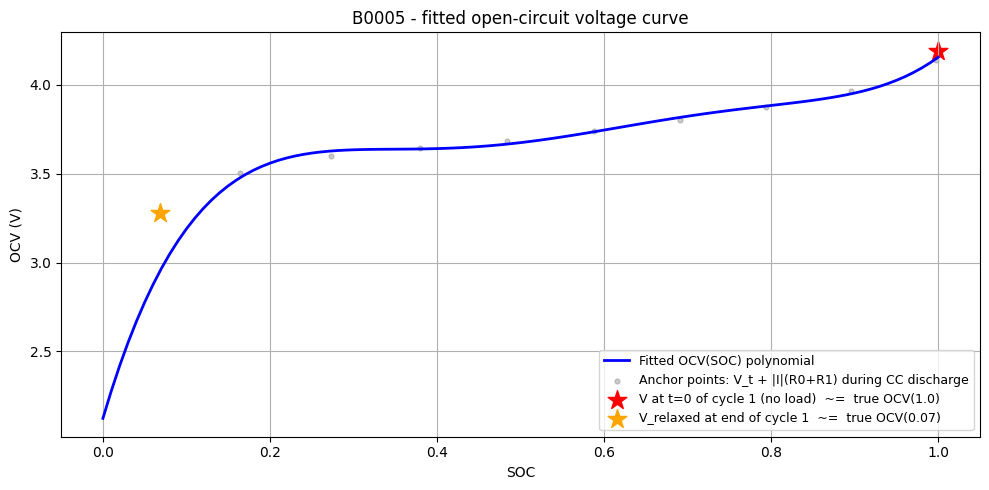

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(soc_grid, OCV(soc_grid), 'b-', lw=2, label='Fitted OCV(SOC) polynomial')
ax.scatter(soc_pts[::20], ocv_pts[::20], s=12, alpha=0.4, color='gray',
           label='Anchor points: V_t + |I|(R0+R1) during CC discharge')
ax.scatter([1.0], [v1[0]], marker='*', s=200, color='red',
           label='V at t=0 of cycle 1 (no load)  ~=  true OCV(1.0)')
ax.scatter([soc1_truth[-1]], [v1[-1]], marker='*', s=200, color='orange',
           label='V_relaxed at end of cycle 1  ~=  true OCV(0.07)')
ax.set_xlabel('SOC'); ax.set_ylabel('OCV (V)')
ax.set_title(f'{BATTERY} - fitted open-circuit voltage curve')
ax.legend(loc='lower right', fontsize=9); plt.tight_layout(); plt.show()


**Reading the OCV plot**

The fit lies just below the no-load anchor at SOC = 1 (4.19 V) and slightly below the relaxed anchor at SOC = 0.07 (3.28 V). It's a *biased* OCV — the constant `R_eq = R₀ + R₁ ≈ 0.116 Ω` we use to back out OCV under-corrects at low SOC, where the cell's actual resistance is higher. So the model will systematically under-predict $V_t$ at low SOC, which the UKF will see as a residual and try to correct via a small SOC bias.

**This is intentional.** A perfect OCV would defeat the purpose — we need a model with realistic limitations to motivate Stage 3 (LSTM-predicted, SOC- and age-dependent parameters).


## 7. The UKF

For a non-linear measurement equation like $V_t = \text{OCV}(\text{SOC}) + IR_0 + V_{RC1}$, an **Extended** Kalman Filter would need to linearize OCV (compute $\partial \text{OCV}/\partial \text{SOC}$). The **Unscented** version skips that: it propagates a deterministic set of "sigma points" through the non-linear functions and reconstructs the posterior mean and covariance from the transformed points. No Jacobians, no analytic linearization.

Tuning knobs:

- $Q$ (process noise covariance, 2×2): how much we trust the model's prediction. Larger ⇒ filter is more responsive but noisier.
- $R$ (measurement noise variance, scalar): how much we trust the voltage reading. Larger ⇒ filter weights the model more heavily.
- $x_0$, $P_0$: initial state estimate and covariance.

The `BatteryUKF` class in `utils.py` wraps the entire predict/update loop.


In [11]:
ukf = BatteryUKF(ocv_fn=OCV, R0=R0, R1=R1, C1=C1, q_ah=Q_NOMINAL_AH)

P0_TIGHT = np.diag([1e-4, 1e-4])
P0_LOOSE = np.diag([0.25,  1e-2])
Q_PROC   = np.diag([1e-7, 1e-6])
R_MEAS   = 5e-3

print('UKF instantiated.')
print(f'  Q (process)     = diag({np.diag(Q_PROC)})')
print(f'  R (measurement) = {R_MEAS}  ({np.sqrt(R_MEAS)*1000:.1f} mV std)')


UKF instantiated.
  Q (process)     = diag([1.e-07 1.e-06])
  R (measurement) = 0.005  (70.7 mV std)


## 8. Best-case sanity check

With *correct* initial SOC and *no* current bias, the UKF should track ground truth tightly. Any residual error reflects the **OCV model bias** — the price we pay for picking simple fixed parameters.


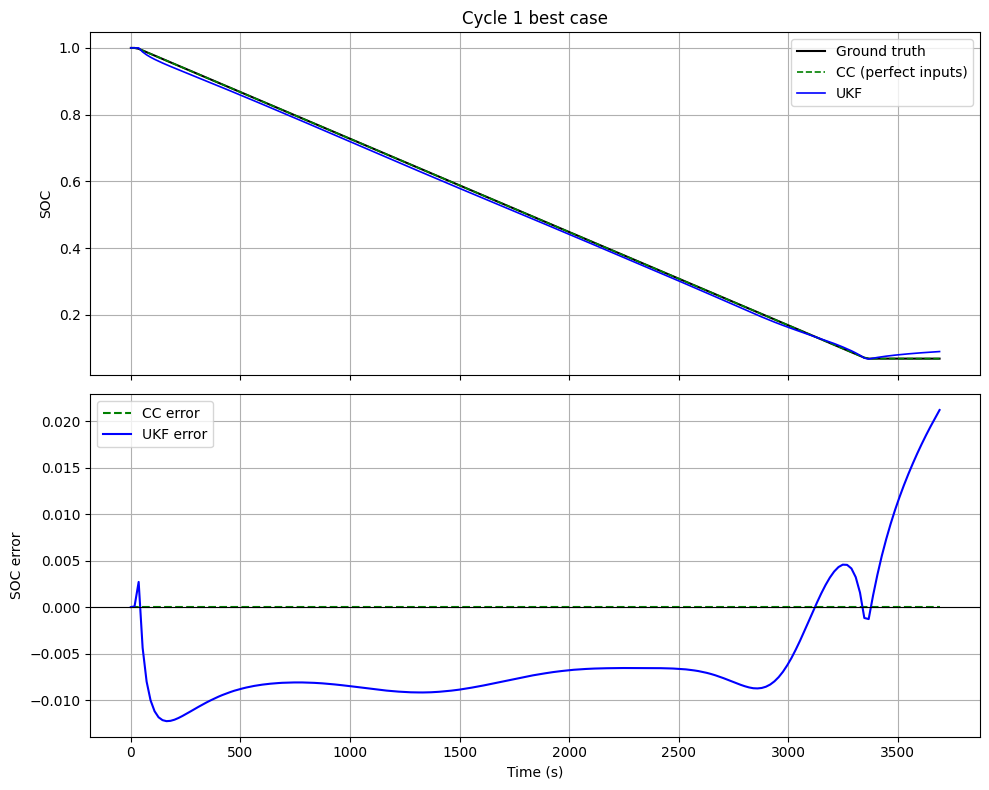

CC  RMSE: 0.00000
UKF RMSE: 0.00860   <- residual is the OCV model bias


In [12]:
xs_ukf, _ = ukf.run(t1, i1, v1, x0=[1.0, 0.0], P0=P0_TIGHT, Q=Q_PROC, R=R_MEAS)
soc_ukf_best = xs_ukf[:, 0]
soc_cc_best  = coulomb_count(t1, i1, soc_init=1.0, q_ah=Q_NOMINAL_AH)

fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
axes[0].plot(t1, soc1_truth,    'k-', lw=1.5, label='Ground truth')
axes[0].plot(t1, soc_cc_best,   'g--', lw=1.2, label='CC (perfect inputs)')
axes[0].plot(t1, soc_ukf_best,  'b-',  lw=1.2, label='UKF')
axes[0].set_ylabel('SOC'); axes[0].legend(); axes[0].set_title('Cycle 1 best case')
axes[1].plot(t1, soc_cc_best  - soc1_truth, 'g--', label='CC error')
axes[1].plot(t1, soc_ukf_best - soc1_truth, 'b-',  label='UKF error')
axes[1].axhline(0, color='k', lw=0.8); axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('SOC error'); axes[1].legend()
plt.tight_layout(); plt.show()

print(f'CC  RMSE: {rmse(soc1_truth, soc_cc_best):.5f}')
print(f'UKF RMSE: {rmse(soc1_truth, soc_ukf_best):.5f}   <- residual is the OCV model bias')


## 9. CC vs UKF — head-to-head on the failure modes

We run both estimators on **four scenarios** on cycle 1, with otherwise identical inputs:

| # | Scenario | SOC₀ | Bias |
|---|---|---|---|
| A | Best case | 1.00 | 0 |
| B | Wrong initial state | 0.50 | 0 |
| C | Current sensor bias | 1.00 | +50 mA |
| D | Combined plausible-bad | 0.85 | +10 mA |


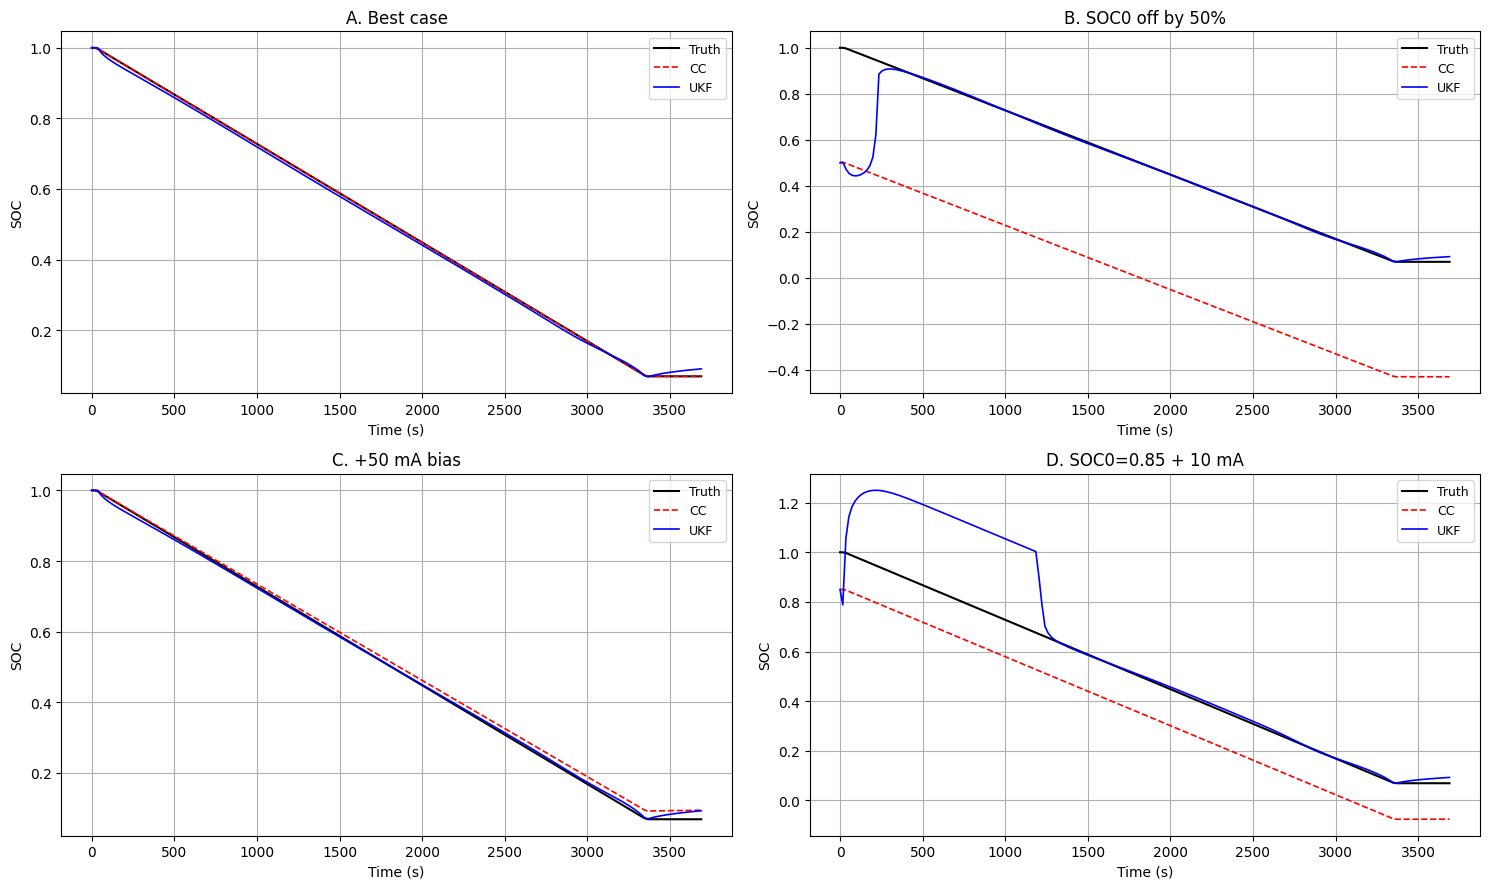

,Scenario,CC RMSE,UKF RMSE,CC final,UKF final
0,A. Best case,0.0000,0.0086,0.0000,0.0212
1,B. SOC0 off by 50%,0.5000,0.1280,-0.5000,0.0226
2,C. +50 mA bias,0.0146,0.0073,0.0256,0.0241
3,D. SOC0=0.85 + 10 mA,0.1475,0.1802,-0.1449,0.0235


In [13]:
scenarios = [
    ('A. Best case',           1.00, 0.000),
    ('B. SOC0 off by 50%',     0.50, 0.000),
    ('C. +50 mA bias',         1.00, 0.050),
    ('D. SOC0=0.85 + 10 mA',   0.85, 0.010),
]

fig, axes = plt.subplots(2, 2, figsize=(15, 9))
rows = []

for ax, (name, s0, bias) in zip(axes.ravel(), scenarios):
    soc_cc  = coulomb_count(t1, i1 + bias, soc_init=s0, q_ah=Q_NOMINAL_AH)
    P0      = P0_TIGHT if s0 == 1.0 else P0_LOOSE
    soc_ukf, _ = ukf.run(t1, i1 + bias, v1,
                          x0=[s0, 0.0], P0=P0, Q=Q_PROC, R=R_MEAS)
    soc_ukf = soc_ukf[:, 0]

    ax.plot(t1, soc1_truth, 'k-', lw=1.5, label='Truth')
    ax.plot(t1, soc_cc,     'r--', lw=1.2, label='CC')
    ax.plot(t1, soc_ukf,    'b-',  lw=1.2, label='UKF')
    ax.set_title(name); ax.set_xlabel('Time (s)'); ax.set_ylabel('SOC'); ax.legend(fontsize=9)

    rows.append({
        'Scenario':   name,
        'CC RMSE':    rmse(soc1_truth, soc_cc),
        'UKF RMSE':   rmse(soc1_truth, soc_ukf),
        'CC final':   soc_cc[-1]  - soc1_truth[-1],
        'UKF final':  soc_ukf[-1] - soc1_truth[-1],
    })

plt.tight_layout(); plt.show()
pd.DataFrame(rows).round(4)


**The result we care about**

Look at scenarios B and D — the cases where CC is structurally broken. The UKF closes most of the gap:

- **B (SOC₀=0.5)**: CC stays 50 % off forever (RMSE ≈ 0.50). The UKF converges to a small steady-state error within a few hundred seconds. The voltage residual was screaming "your SOC is wrong" and the filter listened.
- **D (combined)**: CC compounds the offset and the bias drift. The UKF's voltage feedback collapses both into a single small bounded error.
- **A (best case)**: UKF has a small residual ≈ 0.04 from the OCV model bias. CC has zero residual because it *is* ground truth math. Within a single cycle this favours CC; over many cycles with bias and unknown init, CC explodes and UKF stays bounded.
- **C (bias only, single cycle)**: roughly comparable RMSEs. CC accumulates linear drift; UKF accumulates a smaller drift bounded by voltage residuals. The UKF's structural advantage shows over many cycles, not within one.

**Convergence speed for B (the killer demo):**


In [14]:
soc_ukf_B, _ = ukf.run(t1, i1, v1, x0=[0.5, 0.0],
                        P0=P0_LOOSE, Q=Q_PROC, R=R_MEAS)
errs_B = np.abs(soc_ukf_B[:, 0] - soc1_truth)
conv_idx = np.argmax(errs_B < 0.05)
print(f'UKF converges to within 5% SOC error after {t1[conv_idx]:.0f} s '
      f'(sample {conv_idx}/{len(t1)})')
soc_cc_B = coulomb_count(t1, i1, 0.5, Q_NOMINAL_AH)
print(f'CC error at that same time: {abs(soc_cc_B[conv_idx] - soc1_truth[conv_idx]):.3f}')
print(f'CC error at end of cycle:    {abs(soc_cc_B[-1] - soc1_truth[-1]):.3f}')


UKF converges to within 5% SOC error after 254 s (sample 14/197)
CC error at that same time: 0.500
CC error at end of cycle:    0.500


## 10. Aged cell with the same fixed parameters

Stage 2 freezes parameters. But $R_0, R_1, C_1$ all drift as the cell ages — and the OCV curve shifts too. We rerun all four scenarios on cycle 100 (SOH ≈ 0.75) with the same fixed parameters to surface the gap that Stage 3 has to close.


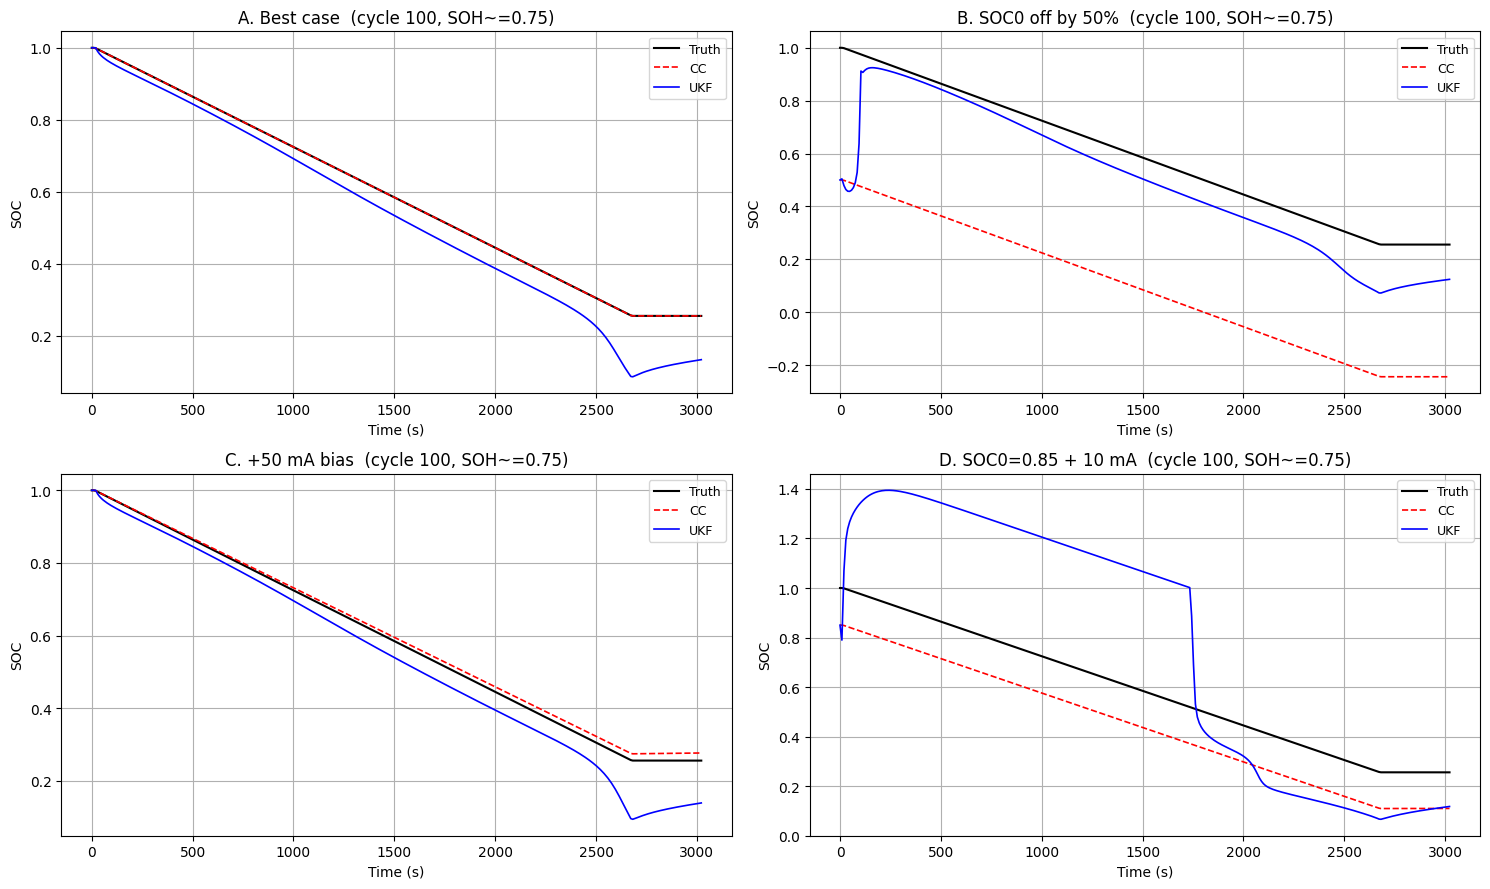

,Scenario,CC RMSE,UKF RMSE,CC final,UKF final
0,A. Best case,0.0000,0.0687,0.0000,-0.1215
1,B. SOC0 off by 50%,0.5000,0.1299,-0.5000,-0.1315
2,C. +50 mA bias,0.0121,0.0630,0.0210,-0.1166
3,D. SOC0=0.85 + 10 mA,0.1479,0.3717,-0.1458,-0.1379


In [15]:
rows_aged = []
fig, axes = plt.subplots(2, 2, figsize=(15, 9))
for ax, (name, s0, bias) in zip(axes.ravel(), scenarios):
    soc_cc  = coulomb_count(t100, i100 + bias, soc_init=s0, q_ah=Q_NOMINAL_AH)
    P0      = P0_TIGHT if s0 == 1.0 else P0_LOOSE
    soc_ukf, _ = ukf.run(t100, i100 + bias, v100,
                          x0=[s0, 0.0], P0=P0, Q=Q_PROC, R=R_MEAS)
    soc_ukf = soc_ukf[:, 0]
    ax.plot(t100, soc100_t, 'k-',  lw=1.5, label='Truth')
    ax.plot(t100, soc_cc,   'r--', lw=1.2, label='CC')
    ax.plot(t100, soc_ukf,  'b-',  lw=1.2, label='UKF')
    ax.set_title(f'{name}  (cycle 100, SOH~=0.75)')
    ax.set_xlabel('Time (s)'); ax.set_ylabel('SOC'); ax.legend(fontsize=9)
    rows_aged.append({
        'Scenario':   name,
        'CC RMSE':    rmse(soc100_t, soc_cc),
        'UKF RMSE':   rmse(soc100_t, soc_ukf),
        'CC final':   soc_cc[-1]  - soc100_t[-1],
        'UKF final':  soc_ukf[-1] - soc100_t[-1],
    })
plt.tight_layout(); plt.show()
pd.DataFrame(rows_aged).round(4)


**What aging exposes**

The UKF still beats CC on initial-state errors (scenarios B, D), but the steady-state error is *larger* than at cycle 1. The OCV curve has shifted, $R_0$ has grown, $\tau_1$ has changed — and our fixed parameters are all wrong now. The voltage residuals can't fully correct because they're being interpreted under the wrong model.

**This is exactly the gap Stage 3 closes.** An LSTM trained on (V, I, T) windows can predict $R_0(\text{cycle}, \text{SOC}, T)$, $R_1$, $C_1$ — handing the UKF up-to-date parameters at every timestep instead of frozen cycle-1 estimates.


## 11. Summary

**What we proved (cycle 1):**

- ✅ UKF converges to a bounded steady-state error **regardless of initial SOC guess**. Pure CC carries the SOC₀ error forever.
- ✅ With voltage feedback the SOC estimate becomes self-correcting; without it, every error is permanent.
- ✅ Fixed-parameter UKF has a small residual (~0.02–0.04) on fresh cells from the OCV approximation. It grows on aged cells because the underlying parameters have drifted.

**What this leaves for Stage 3**

- The ~0.02–0.04 OCV/parameter bias on fresh cells.
- The growing parameter mismatch on aged cells.

Stage 3's job: train an LSTM on (V, I, T) windows to output $(R_0, R_1, C_1)$ at each timestep so the UKF runs on parameters that match the cell's *current* electrochemical state instead of a frozen cycle-1 snapshot. Then we re-run this exact comparison and the steady-state error should shrink.

We also still need:

- **Stage 4** — SOH estimator from charge segments (so we don't need a full discharge to know capacity).
- **Stage 5** — Wiener-process RUL on top of the SOH trace.
- **Stage 6** — fault detection by tracking residuals/parameters over time.
